# DataCo Classical ML Baselines

This notebook follows the repository pipeline on the DataCo Smart Supply Chain dataset:

1. preprocess the raw transactional table,
2. build wrapper-selected and PCA feature spaces,
3. train Keras linear/logistic, Decision Tree, Random Forest, and XGBoost baselines,
4. compare the models using the report methodology.

Methodology source: the linked Google Doc was not readable as static HTML, so the local PDF fallback was used: `C:/Users/User/Downloads/ML_Partial_Report.docx.pdf`. The implemented protocol uses chronological 70/15/15 train/validation/test splits, late-delivery classification metrics, and sales-regression metrics. Large intermediate feature matrices are generated in memory; set `SAVE_FEATURE_TABLES = True` only when local CSV exports are needed.

In [1]:

from pathlib import Path
from dataclasses import dataclass
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier, XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
SAVE_FEATURE_TABLES = False
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
RAW_PATH = ROOT / "transactional" / "DataCoSupplyChainDataset.csv"
OUT_DIR = ROOT / "model" / "Classical"
CSV_DIR = OUT_DIR / "csv"
FIG_DIR = OUT_DIR / "figure"
PREP_DIR = ROOT / "classical_preprocessing"
for path in [CSV_DIR, FIG_DIR, PREP_DIR, ROOT / "wrapper", ROOT / "PCA"]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


## Model Architecture Summary

- **Logistic / Linear Regression (Keras):** `Input(n_features) -> Dense(1, sigmoid/linear)`.
- **Decision Tree:** one CART tree with depth and leaf-size controls.
- **Random Forest:** bagged CART ensemble with balanced classification weights.
- **XGBoost:** gradient-boosted tree ensemble using histogram tree construction.

The same split and feature view are passed to every model for fair comparison.

In [2]:

@dataclass(frozen=True)
class TaskSpec:
    name: str
    slug: str
    target: str
    kind: str
    leakage: tuple[str, ...]

COMMON_DROP = (
    "Customer Email", "Customer Fname", "Customer Lname", "Customer Password", "Customer Street",
    "Product Description", "Product Image", "order date (DateOrders)", "shipping date (DateOrders)",
    "Category Id", "Customer Id", "Department Id", "Order Customer Id", "Order Id",
    "Order Item Cardprod Id", "Order Item Id", "Product Card Id", "Product Category Id",
)

TASKS = [
    TaskSpec(
        name="Late Delivery Classification",
        slug="late_delivery",
        target="Late_delivery_risk",
        kind="classification",
        leakage=("Delivery Status", "Days for shipping (real)", "Sales_winsorized"),
    ),
    TaskSpec(
        name="Sales Forecasting",
        slug="sales",
        target="Sales_winsorized",
        kind="regression",
        leakage=(
            "Sales", "Order Item Total", "Benefit per order", "Order Profit Per Order",
            "Order Item Profit Ratio", "Sales per customer",
        ),
    ),
]

VIEW_NAMES = ("Prepared", "Wrapper", "PCA")


In [3]:

def load_raw_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="latin1")
    df["order_dt"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
    df = df.sort_values("order_dt", na_position="last").reset_index(drop=True)

    order_dt = df["order_dt"]
    df["order_year"] = order_dt.dt.year
    df["order_quarter"] = order_dt.dt.quarter
    df["order_month"] = order_dt.dt.month
    df["order_day"] = order_dt.dt.day
    df["order_weekday"] = order_dt.dt.weekday
    df["order_hour"] = order_dt.dt.hour
    df["order_is_weekend"] = order_dt.dt.weekday.isin([5, 6]).astype(int)

    lo, hi = df["Sales"].quantile([0.01, 0.99])
    df["Sales_winsorized"] = df["Sales"].clip(lo, hi)
    df = df.drop(columns=["order_dt"])
    return df

raw = load_raw_data(RAW_PATH)
print(raw.shape)
display(raw[["Late_delivery_risk", "Sales", "Sales_winsorized", "order_year", "order_month"]].head())


(180519, 61)


,Late_delivery_risk,Sales,Sales_winsorized,order_year,order_month
0,0,299.9800,299.9800,2015,1
1,0,199.9900,199.9900,2015,1
2,0,250.0000,250.0000,2015,1
3,0,129.9900,129.9900,2015,1
4,1,199.9200,199.9200,2015,1


In [4]:

def chronological_split(n_rows: int):
    train_end = int(n_rows * 0.70)
    val_end = int(n_rows * 0.85)
    return slice(0, train_end), slice(train_end, val_end), slice(val_end, n_rows)


def make_preprocessor(X_train: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]
    return ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]),
                categorical_cols,
            ),
        ],
        verbose_feature_names_out=False,
    )


def to_frame(array, columns):
    return pd.DataFrame(np.asarray(array), columns=columns)


def save_view(task, view, arrays, columns, ys):
    if not SAVE_FEATURE_TABLES:
        return
    parts = []
    for split_name, X, y in zip(["train", "validation", "test"], arrays, ys):
        frame = pd.DataFrame(X, columns=columns)
        frame.insert(0, "split", split_name)
        frame[task.target] = y
        parts.append(frame)
    target_dir = PREP_DIR if view == "prepared_numeric" else ROOT / ("PCA" if view.startswith("pca") else "wrapper")
    target_dir.mkdir(parents=True, exist_ok=True)
    pd.concat(parts, ignore_index=True).to_csv(target_dir / f"{task.slug}_{view}.csv", index=False)


def build_feature_views(df: pd.DataFrame, task: TaskSpec):
    drop_cols = set(COMMON_DROP) | set(task.leakage) | {task.target}
    X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    X_raw = X_raw.loc[:, X_raw.nunique(dropna=False) > 1]
    y = df[task.target].astype(int if task.kind == "classification" else float)

    tr, va, te = chronological_split(len(df))
    X_train_raw, X_val_raw, X_test_raw = X_raw.iloc[tr], X_raw.iloc[va], X_raw.iloc[te]
    y_train, y_val, y_test = y.iloc[tr].to_numpy(), y.iloc[va].to_numpy(), y.iloc[te].to_numpy()

    pre = make_preprocessor(X_train_raw)
    X_train_base = to_frame(pre.fit_transform(X_train_raw), pre.get_feature_names_out())
    X_val_base = to_frame(pre.transform(X_val_raw), X_train_base.columns)
    X_test_base = to_frame(pre.transform(X_test_raw), X_train_base.columns)

    scaler = StandardScaler().fit(X_train_base)
    X_train_prepared = scaler.transform(X_train_base)
    X_val_prepared = scaler.transform(X_val_base)
    X_test_prepared = scaler.transform(X_test_base)

    selector_estimator = (
        LogisticRegression(max_iter=1500, solver="liblinear", class_weight="balanced", random_state=SEED)
        if task.kind == "classification"
        else Ridge(alpha=1.0, random_state=SEED)
    )
    n_keep = min(max(8, int(X_train_base.shape[1] * 0.55)), X_train_base.shape[1])
    selector = RFE(selector_estimator, n_features_to_select=n_keep, step=0.20)
    selector.fit(X_train_prepared, y_train)
    selected_cols = X_train_base.columns[selector.support_].tolist()

    X_train_wrapper = X_train_prepared[:, selector.support_]
    X_val_wrapper = X_val_prepared[:, selector.support_]
    X_test_wrapper = X_test_prepared[:, selector.support_]

    pca = PCA(n_components=0.95, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_wrapper)
    X_val_pca = pca.transform(X_val_wrapper)
    X_test_pca = pca.transform(X_test_wrapper)
    pca_cols = [f"PC{i + 1}" for i in range(X_train_pca.shape[1])]

    save_view(task, "prepared_numeric", [X_train_prepared, X_val_prepared, X_test_prepared], X_train_base.columns, [y_train, y_val, y_test])
    save_view(task, "wrapper_selected_features_rfe", [X_train_wrapper, X_val_wrapper, X_test_wrapper], selected_cols, [y_train, y_val, y_test])
    save_view(task, "pca_95_variance", [X_train_pca, X_val_pca, X_test_pca], pca_cols, [y_train, y_val, y_test])

    return {
        "task": task,
        "y": {"train": y_train, "validation": y_val, "test": y_test},
        "views": {
            "Prepared": (X_train_prepared, X_val_prepared, X_test_prepared, X_train_base.columns.tolist()),
            "Wrapper": (X_train_wrapper, X_val_wrapper, X_test_wrapper, selected_cols),
            "PCA": (X_train_pca, X_val_pca, X_test_pca, pca_cols),
        },
        "selected_features": selected_cols,
        "pca_components": len(pca_cols),
        "pca_variance": float(pca.explained_variance_ratio_.sum()),
    }

bundles = {task.slug: build_feature_views(raw, task) for task in TASKS}
summary = pd.DataFrame([
    {
        "task": b["task"].name,
        "prepared_features": len(b["views"]["Prepared"][3]),
        "wrapper_features": len(b["selected_features"]),
        "pca_components": b["pca_components"],
        "pca_variance": b["pca_variance"],
    }
    for b in bundles.values()
])
display(summary)


,task,prepared_features,wrapper_features,pca_components,pca_variance
0,Late Delivery Classification,38,20,12,0.9582
1,Sales Forecasting,35,19,14,0.9708


In [5]:

def class_weights(y):
    values, counts = np.unique(y, return_counts=True)
    total = counts.sum()
    return {int(v): total / (len(values) * c) for v, c in zip(values, counts)}


def best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])


def safe_auc(fn, y_true, score):
    try:
        return float(fn(y_true, score))
    except ValueError:
        return np.nan


def classification_metrics(y_test, score, threshold):
    pred = (score >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": safe_auc(roc_auc_score, y_test, score),
        "pr_auc": safe_auc(average_precision_score, y_test, score),
        "threshold": threshold,
    }


def regression_metrics(y_test, pred):
    return {
        "mae": mean_absolute_error(y_test, pred),
        "rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "r2": r2_score(y_test, pred),
    }


def keras_linear(task: TaskSpec, n_features: int):
    activation = "sigmoid" if task.kind == "classification" else "linear"
    loss = "binary_crossentropy" if task.kind == "classification" else "mse"
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(1, activation=activation, name="linear_output"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss=loss)
    return model


def sklearn_models(task: TaskSpec, y_train):
    if task.kind == "classification":
        neg = max((y_train == 0).sum(), 1)
        pos = max((y_train == 1).sum(), 1)
        return {
            "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=75, class_weight="balanced", random_state=SEED),
            "Random Forest": RandomForestClassifier(n_estimators=80, max_depth=14, min_samples_leaf=30, class_weight="balanced", n_jobs=-1, random_state=SEED),
            "XGBoost": XGBClassifier(n_estimators=120, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, objective="binary:logistic", eval_metric="logloss", tree_method="hist", scale_pos_weight=neg / pos, n_jobs=-1, random_state=SEED),
        }
    return {
        "Decision Tree": DecisionTreeRegressor(max_depth=14, min_samples_leaf=50, random_state=SEED),
        "Random Forest": RandomForestRegressor(n_estimators=80, max_depth=16, min_samples_leaf=20, n_jobs=-1, random_state=SEED),
        "XGBoost": XGBRegressor(n_estimators=160, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror", tree_method="hist", n_jobs=-1, random_state=SEED),
    }


In [6]:

def fit_keras_baseline(task, view_name, X_train, X_val, X_test, y_train, y_val, y_test):
    model = keras_linear(task, X_train.shape[1])
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)]
    fit_kwargs = dict(epochs=30, batch_size=1024, validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)

    if task.kind == "classification":
        fit_kwargs["class_weight"] = class_weights(y_train)
        model.fit(X_train.astype("float32"), y_train, **fit_kwargs)
        val_score = model.predict(X_val.astype("float32"), verbose=0).ravel()
        test_score = model.predict(X_test.astype("float32"), verbose=0).ravel()
        metrics = classification_metrics(y_test, test_score, best_f1_threshold(y_val, val_score))
        model_name = "Logistic Regression (Keras)"
    else:
        y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
        y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
        y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
        fit_kwargs["validation_data"] = (X_val, y_val_s)
        model.fit(X_train.astype("float32"), y_train_s, **fit_kwargs)
        pred_s = model.predict(X_test.astype("float32"), verbose=0).ravel()
        pred = y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()
        metrics = regression_metrics(y_test, pred)
        model_name = "Linear Regression (Keras)"

    return {"task": task.name, "view": view_name, "model": model_name, **metrics}


def fit_tree_baseline(task, view_name, model_name, model, X_train, X_val, X_test, y_train, y_val, y_test):
    model.fit(X_train, y_train)
    if task.kind == "classification":
        val_score = model.predict_proba(X_val)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
        metrics = classification_metrics(y_test, test_score, best_f1_threshold(y_val, val_score))
    else:
        metrics = regression_metrics(y_test, model.predict(X_test))
    return {"task": task.name, "view": view_name, "model": model_name, **metrics}


rows = []
for bundle in bundles.values():
    task = bundle["task"]
    y = bundle["y"]
    for view_name, (X_train, X_val, X_test, _) in bundle["views"].items():
        print(f"{task.name} | {view_name} | Keras linear")
        rows.append(fit_keras_baseline(task, view_name, X_train, X_val, X_test, y["train"], y["validation"], y["test"]))

        for model_name, model in sklearn_models(task, y["train"]).items():
            print(f"{task.name} | {view_name} | {model_name}")
            rows.append(fit_tree_baseline(task, view_name, model_name, model, X_train, X_val, X_test, y["train"], y["validation"], y["test"]))

results = pd.DataFrame(rows)
results.to_csv(CSV_DIR / "classical_baseline_results.csv", index=False)
display(results)


Late Delivery Classification | Prepared | Keras linear


Late Delivery Classification | Prepared | Decision Tree


Late Delivery Classification | Prepared | Random Forest


Late Delivery Classification | Prepared | XGBoost


Late Delivery Classification | Wrapper | Keras linear


...

Sales Forecasting | PCA | Keras linear


Sales Forecasting | PCA | Decision Tree


Sales Forecasting | PCA | Random Forest


Sales Forecasting | PCA | XGBoost


,task,view,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,mae,rmse,r2
0,Late Delivery Classification,Prepared,Logistic Regression (Keras),0.5623,0.5570,1.0000,0.7154,0.7317,0.7983,0.2284,NaN,NaN,NaN
1,Late Delivery Classification,Prepared,Decision Tree,0.6196,0.5916,0.9966,0.7425,0.7979,0.8393,0.1025,NaN,NaN,NaN
2,Late Delivery Classification,Prepared,Random Forest,0.6135,0.5877,0.9970,0.7395,0.7991,0.8590,0.3018,NaN,NaN,NaN
3,Late Delivery Classification,Prepared,XGBoost,0.6192,0.5910,0.9995,0.7428,0.8019,0.8607,0.2672,NaN,NaN,NaN
4,Late Delivery Classification,Wrapper,Logistic Regression (Keras),0.5624,0.5570,0.9999,0.7155,0.7324,0.7991,0.2308,NaN,NaN,NaN
5,Late Delivery Classification,Wrapper,Decision Tree,0.6211,0.5936,0.9872,0.7414,0.7993,0.8200,0.2737,NaN,NaN,NaN
6,Late Delivery Classification,Wrapper,Random Forest,0.6155,0.5894,0.9933,0.7398,0.7983,0.8595,0.3117,NaN,NaN,NaN
7,Late Delivery Classification,Wrapper,XGBoost,0.6231,0.5944,0.9919,0.7433,0.8003,0.8596,0.3241,NaN,NaN,NaN
8,Late Delivery Classification,PCA,Logistic Regression (Keras),0.5524,0.5518,0.9930,0.7094,0.7197,0.7798,0.2786,NaN,NaN,NaN
9,Late Delivery Classification,PCA,Decision Tree,0.6121,0.5881,0.9842,0.7363,0.7834,0.8327,0.2789,NaN,NaN,NaN


In [7]:

classification_results = results[results["task"].str.contains("Classification")].copy()
regression_results = results[results["task"].str.contains("Forecasting")].copy()

classification_table = classification_results[
    ["view", "model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold"]
].sort_values(["view", "f1"], ascending=[True, False])

regression_table = regression_results[
    ["view", "model", "mae", "rmse", "r2"]
].sort_values(["view", "rmse"], ascending=[True, True])

classification_table.to_csv(CSV_DIR / "late_delivery_classification_comparison.csv", index=False)
regression_table.to_csv(CSV_DIR / "sales_regression_comparison.csv", index=False)

print("Late delivery classification: higher accuracy, precision, recall, F1, ROC-AUC, and PR-AUC are better.")
display(classification_table)

print("Sales forecasting: lower MAE/RMSE and higher R2 are better.")
display(regression_table)


Late delivery classification: higher accuracy, precision, recall, F1, ROC-AUC, and PR-AUC are better.


,view,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
11,PCA,XGBoost,0.6118,0.5876,0.9870,0.7367,0.7875,0.8497,0.3300
9,PCA,Decision Tree,0.6121,0.5881,0.9842,0.7363,0.7834,0.8327,0.2789
10,PCA,Random Forest,0.5906,0.5748,0.9826,0.7253,0.7690,0.8382,0.3214
8,PCA,Logistic Regression (Keras),0.5524,0.5518,0.9930,0.7094,0.7197,0.7798,0.2786
3,Prepared,XGBoost,0.6192,0.5910,0.9995,0.7428,0.8019,0.8607,0.2672
1,Prepared,Decision Tree,0.6196,0.5916,0.9966,0.7425,0.7979,0.8393,0.1025
2,Prepared,Random Forest,0.6135,0.5877,0.9970,0.7395,0.7991,0.8590,0.3018
0,Prepared,Logistic Regression (Keras),0.5623,0.5570,1.0000,0.7154,0.7317,0.7983,0.2284
7,Wrapper,XGBoost,0.6231,0.5944,0.9919,0.7433,0.8003,0.8596,0.3241
5,Wrapper,Decision Tree,0.6211,0.5936,0.9872,0.7414,0.7993,0.8200,0.2737


Sales forecasting: lower MAE/RMSE and higher R2 are better.


,view,model,mae,rmse,r2
23,PCA,XGBoost,26.4832,49.4998,0.8602
22,PCA,Random Forest,28.5739,57.0825,0.8140
21,PCA,Decision Tree,28.2313,57.7658,0.8096
20,PCA,Linear Regression (Keras),38.2540,140.7385,-0.1304
15,Prepared,XGBoost,15.9104,33.3881,0.9364
14,Prepared,Random Forest,17.3514,40.5714,0.9061
13,Prepared,Decision Tree,22.5311,54.2327,0.8321
12,Prepared,Linear Regression (Keras),36.5914,141.9940,-0.1506
17,Wrapper,Decision Tree,13.9349,30.4810,0.9470
19,Wrapper,XGBoost,16.4584,34.9204,0.9304


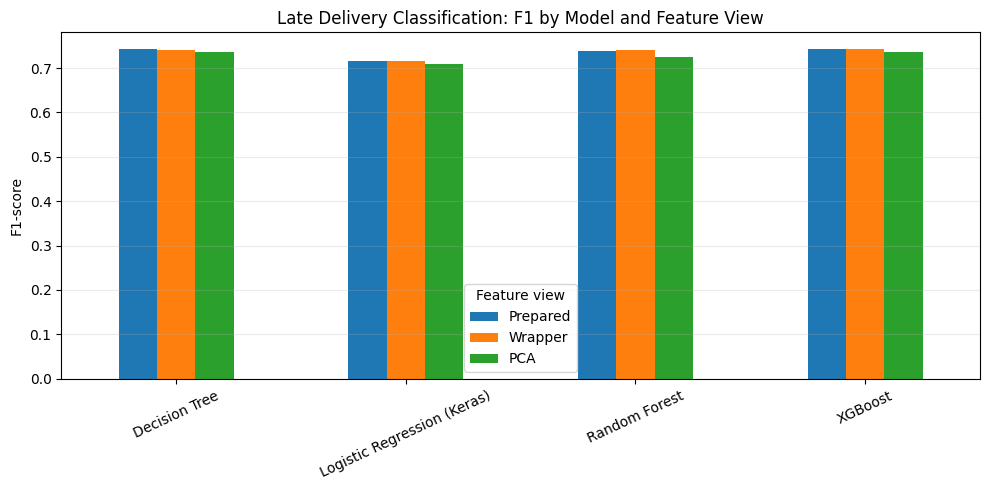

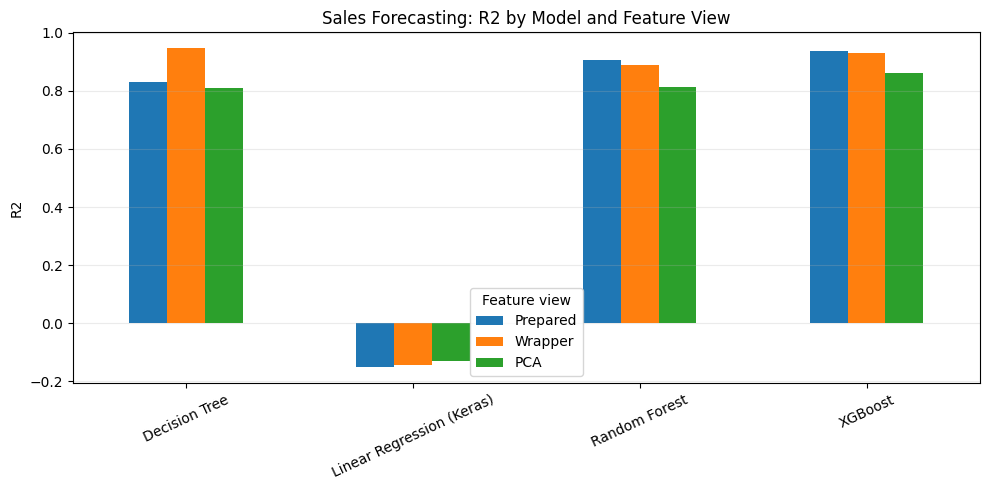

In [8]:

def plot_comparison(df, metric, title, ylabel, path):
    pivot = df.pivot(index="model", columns="view", values=metric).reindex(columns=VIEW_NAMES)
    ax = pivot.plot(kind="bar", figsize=(10, 5), rot=25)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Feature view")
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()

plot_comparison(classification_results, "f1", "Late Delivery Classification: F1 by Model and Feature View", "F1-score", FIG_DIR / "late_delivery_f1_comparison.png")
plot_comparison(regression_results, "r2", "Sales Forecasting: R2 by Model and Feature View", "R2", FIG_DIR / "sales_r2_comparison.png")


## Interpretation Guide

- Use the **Prepared** view as the baseline feature matrix.
- Use the **Wrapper** view to evaluate whether estimator-driven feature selection improves generalization.
- Use the **PCA** view to evaluate whether compressed orthogonal components preserve enough predictive signal.
- For the report, fill the late-delivery table from `late_delivery_classification_comparison.csv` and the sales table from `sales_regression_comparison.csv`.